# 03 - Transformer Baseline Model

This notebook contains the first baseline transformer implementation
for Riichi Mahjong behavioral cloning.

Pipeline:
- SQLite dataset
- semantic tokenization
- tensorization
- batching
- transformer encoder
- policy logits
- supervised behavioral cloning

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [2]:
import sqlite3
import pandas as pd
import gzip
import json

import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
from src.data.tokenizer import MahjongTokenizer

from src.features.tensorization import Tensorizer

from src.data.collator import MahjongCollator

from src.models.transformer_model import (
    MahjongTransformer
)

In [4]:
tokenizer = MahjongTokenizer()

tensorizer = Tensorizer()

collator = MahjongCollator()

model = MahjongTransformer()

In [5]:
conn = sqlite3.connect(
    "../data/raw/datasets_positive.db"
)

query = """
SELECT *
FROM Discard
LIMIT 1 OFFSET 100000
"""

df = pd.read_sql(query, conn)

In [6]:
blob = df.iloc[0]["Data"]

decoded = json.loads(
    gzip.decompress(blob)
)

In [8]:
canonical_state = {
    "round_wind": decoded["round_wind"],
    "num_honba": decoded["num_honba"],
    "num_riichi": decoded["num_riichi"],
    "player_wind": decoded["player_wind"],
    "position": decoded["position"],
    "remain_tiles": decoded["remain_tiles"],

    "dora_indicators": decoded["dora_indicators"],

    "hand_tiles": decoded["hand_tiles"],

    "players": {
        "0": decoded["0"],
        "1": decoded["1"],
        "2": decoded["2"],
        "3": decoded["3"],
    },

    "valid_actions": decoded["valid_actions"],

    "action_idx": decoded["action_idx"],
}

In [9]:
tokens = tokenizer.tokenize(canonical_state)

tensor_dict = tensorizer.tensorize(tokens)

batch = collator.collate([tensor_dict])

In [10]:
logits = model(batch)

In [11]:
print(logits)

[tensor([0.2003, 0.2115, 0.2624, 0.0211, 0.2699, 0.6030, 0.4477, 0.2461, 0.4048,
        0.0176, 0.1296, 0.2447, 0.1598, 0.4901], grad_fn=<SqueezeBackward1>)]


In [12]:
target = torch.tensor([
    canonical_state["action_idx"]
])

print(target)

tensor([7])


In [13]:
criterion = nn.CrossEntropyLoss()

In [14]:
loss = criterion(
    logits[0].unsqueeze(0),
    target,
)

print(loss)

tensor(2.6716, grad_fn=<NllLossBackward0>)


In [15]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
)

In [16]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

In [17]:
model.train()

MahjongTransformer(
  (embedding_layer): MahjongEmbedding(
    (token_type_embedding): Embedding(7, 128)
    (tile_embedding): Embedding(35, 128)
    (copy_embedding): Embedding(5, 128)
    (player_embedding): Embedding(5, 128)
    (action_type_embedding): Embedding(13, 128)
    (position_embedding): Embedding(512, 128)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1

In [18]:
batch = collator.collate([
    tensor_dict
])

In [19]:
target = torch.tensor([
    canonical_state["action_idx"]
])

In [20]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
)

In [21]:
losses = []

for step in range(300):

    optimizer.zero_grad()

    logits = model(batch)

    loss = criterion(
        logits[0].unsqueeze(0),
        target,
    )

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if step % 25 == 0:

        prediction = torch.argmax(
            logits[0]
        ).item()

        print(
            f"Step {step}"
        )

        print(
            f"Loss: {loss.item():.4f}"
        )

        print(
            f"Prediction: {prediction}"
        )

        print(
            f"Target: {target.item()}"
        )

        print()

Step 0
Loss: 2.2424
Prediction: 7
Target: 7

Step 25
Loss: 0.0001
Prediction: 7
Target: 7

Step 50
Loss: 0.0000
Prediction: 7
Target: 7

Step 75
Loss: 0.0000
Prediction: 7
Target: 7

Step 100
Loss: 0.0000
Prediction: 7
Target: 7

Step 125
Loss: 0.0000
Prediction: 7
Target: 7

Step 150
Loss: 0.0000
Prediction: 7
Target: 7

Step 175
Loss: 0.0000
Prediction: 7
Target: 7

Step 200
Loss: 0.0000
Prediction: 7
Target: 7

Step 225
Loss: 0.0000
Prediction: 7
Target: 7

Step 250
Loss: 0.0000
Prediction: 7
Target: 7

Step 275
Loss: 0.0000
Prediction: 7
Target: 7



Text(0.5, 1.0, 'Tiny Batch Overfit Test')

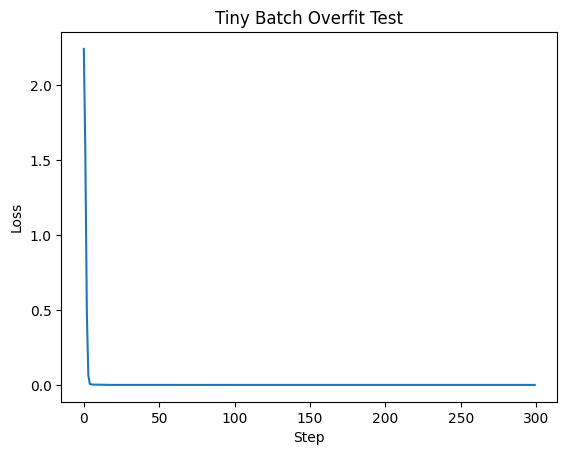

In [22]:
import matplotlib.pyplot as plt

plt.plot(losses)

plt.xlabel("Step")

plt.ylabel("Loss")

plt.title("Tiny Batch Overfit Test")

In [23]:
query = """
SELECT *
FROM Discard
LIMIT 8 OFFSET 100000
"""

df = pd.read_sql(query, conn)

In [24]:
batch_tensor_dicts = []

targets = []

for idx in range(len(df)):

    blob = df.iloc[idx]["Data"]

    decoded = json.loads(
        gzip.decompress(blob)
    )

    canonical_state = {
        "round_wind": decoded["round_wind"],
        "num_honba": decoded["num_honba"],
        "num_riichi": decoded["num_riichi"],
        "player_wind": decoded["player_wind"],
        "position": decoded["position"],
        "remain_tiles": decoded["remain_tiles"],

        "dora_indicators": decoded["dora_indicators"],

        "hand_tiles": decoded["hand_tiles"],

        "players": {
            "0": decoded["0"],
            "1": decoded["1"],
            "2": decoded["2"],
            "3": decoded["3"],
        },

        "valid_actions": decoded["valid_actions"],

        "action_idx": decoded["action_idx"],
    }

    tokens = tokenizer.tokenize(
        canonical_state
    )

    tensor_dict = tensorizer.tensorize(
        tokens
    )

    batch_tensor_dicts.append(
        tensor_dict
    )

    targets.append(
        canonical_state["action_idx"]
    )

In [25]:
batch = collator.collate(
    batch_tensor_dicts
)

In [26]:
targets = torch.tensor(targets)

print(targets)

tensor([ 7,  6,  7, 12, 13, 12, 13,  7])


In [27]:
model = MahjongTransformer()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
)

criterion = nn.CrossEntropyLoss()

In [28]:
losses = []

accuracies = []

for step in range(500):

    optimizer.zero_grad()

    logits_list = model(batch)

    # ============================================
    # Compute batch loss
    # ============================================

    total_loss = 0

    correct = 0

    for i in range(len(logits_list)):

        logits = logits_list[i].unsqueeze(0)

        target = targets[i].unsqueeze(0)

        loss = criterion(
            logits,
            target,
        )

        total_loss += loss

        prediction = torch.argmax(
            logits
        ).item()

        if prediction == target.item():
            correct += 1

    total_loss = total_loss / len(logits_list)

    accuracy = correct / len(logits_list)

    total_loss.backward()

    optimizer.step()

    losses.append(
        total_loss.item()
    )

    accuracies.append(
        accuracy
    )

    if step % 25 == 0:

        print(f"Step {step}")

        print(
            f"Loss: {total_loss.item():.4f}"
        )

        print(
            f"Accuracy: {accuracy:.4f}"
        )

        print()

Step 0
Loss: 2.5137
Accuracy: 0.0000

Step 25
Loss: 0.0180
Accuracy: 1.0000

Step 50
Loss: 0.0001
Accuracy: 1.0000

Step 75
Loss: 0.0000
Accuracy: 1.0000

Step 100
Loss: 0.0000
Accuracy: 1.0000

Step 125
Loss: 0.0000
Accuracy: 1.0000

Step 150
Loss: 0.0000
Accuracy: 1.0000

Step 175
Loss: 0.0000
Accuracy: 1.0000

Step 200
Loss: 0.0000
Accuracy: 1.0000

Step 225
Loss: 0.0000
Accuracy: 1.0000

Step 250
Loss: 0.0000
Accuracy: 1.0000

Step 275
Loss: 0.0000
Accuracy: 1.0000

Step 300
Loss: 0.0000
Accuracy: 1.0000

Step 325
Loss: 0.0000
Accuracy: 1.0000

Step 350
Loss: 0.0000
Accuracy: 1.0000

Step 375
Loss: 0.0000
Accuracy: 1.0000

Step 400
Loss: 0.0000
Accuracy: 1.0000

Step 425
Loss: 0.0000
Accuracy: 1.0000

Step 450
Loss: 0.0000
Accuracy: 1.0000

Step 475
Loss: 0.0000
Accuracy: 1.0000



Text(0.5, 1.0, '8-Sample Overfit Loss')

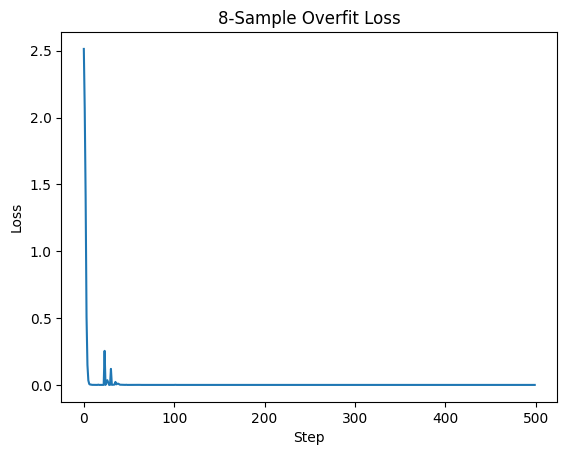

In [30]:
plt.plot(losses)

plt.xlabel("Step")

plt.ylabel("Loss")

plt.title("8-Sample Overfit Loss")

Text(0.5, 1.0, '8-Sample Overfit Accuracy')

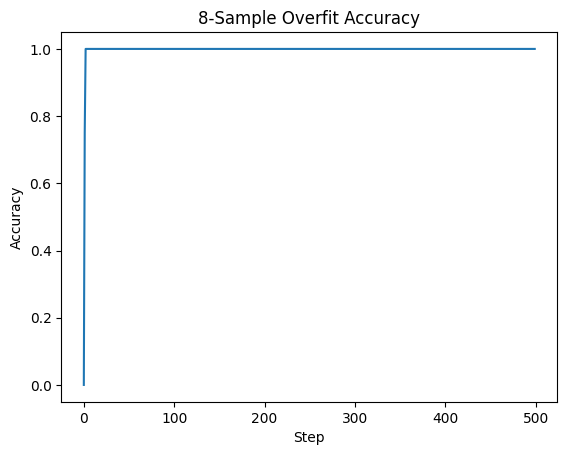

In [29]:
plt.plot(accuracies)

plt.xlabel("Step")

plt.ylabel("Accuracy")

plt.title("8-Sample Overfit Accuracy")

In [6]:
from torch.utils.data import DataLoader

from src.data.dataset import MahjongDataset

In [7]:
dataset = MahjongDataset(
    db_path="../data/raw/datasets_positive.db",

    table_name="Discard",

    limit=1000,
)

In [8]:
print(len(dataset))

1000


In [9]:
sample = dataset[0]

In [10]:
sample.keys()

dict_keys(['token_type_ids', 'tile_ids', 'copy_ids', 'player_ids', 'action_type_ids', 'positions', 'action_mask', 'action_indices', 'target'])

In [11]:
dataloader = DataLoader(
    dataset,

    batch_size=8,

    shuffle=True,

    collate_fn=collator.collate,
)

In [12]:
batch = next(iter(dataloader))

In [13]:
for key, value in batch.items():

    print()

    print(key)

    if isinstance(value, list):
        print(value)

    else:
        print(value.shape)


token_type_ids
torch.Size([8, 83])

tile_ids
torch.Size([8, 83])

copy_ids
torch.Size([8, 83])

player_ids
torch.Size([8, 83])

action_type_ids
torch.Size([8, 83])

positions
torch.Size([8, 83])

attention_mask
torch.Size([8, 83])

action_mask
torch.Size([8, 83])

action_indices
[tensor([44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]), tensor([39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]), tensor([64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77]), tensor([39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]), tensor([72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82]), tensor([64, 65, 66, 67, 68, 69, 70, 71]), tensor([30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]), tensor([46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56])]

target
torch.Size([8])


In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [15]:
model = MahjongTransformer().to(device)

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [16]:
train_dataset = MahjongDataset(
    db_path="../data/raw/datasets_positive.db",

    table_name="Discard",

    limit=10000,

    offset=0,
)

val_dataset = MahjongDataset(
    db_path="../data/raw/datasets_positive.db",

    table_name="Discard",

    limit=1000,

    offset=10000,
)

In [17]:
train_loader = DataLoader(
    train_dataset,

    batch_size=32,

    shuffle=True,

    collate_fn=collator.collate,
)

val_loader = DataLoader(
    val_dataset,

    batch_size=32,

    shuffle=False,

    collate_fn=collator.collate,
)

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
)

In [19]:
def move_batch_to_device(batch, device):

    moved = {}

    for key, value in batch.items():

        if isinstance(value, list):

            moved[key] = [
                v.to(device)
                for v in value
            ]

        else:

            moved[key] = value.to(device)

    return moved

In [24]:
train_losses = []

train_accuracies = []

val_losses = []

val_accuracies = []

for epoch in range(3):

    model.train()

    epoch_loss = 0

    epoch_correct = 0

    epoch_total = 0

    for batch in train_loader:

        batch = move_batch_to_device(
            batch,
            device,
        )

        targets = batch["target"].to(device)

        optimizer.zero_grad()

        logits_list = model(batch)

        total_loss = 0

        correct = 0

        # ============================================
        # Per-sample legal action losses
        # ============================================

        for i in range(len(logits_list)):

            logits = logits_list[i].unsqueeze(0)

            target = targets[i].unsqueeze(0)

            loss = criterion(
                logits,
                target,
            )

            total_loss += loss

            prediction = torch.argmax(
                logits
            ).item()

            if prediction == target.item():
                correct += 1

        total_loss = (
            total_loss / len(logits_list)
        )

        total_loss.backward()

        optimizer.step()

        batch_accuracy = (
            correct / len(logits_list)
        )

        epoch_loss += total_loss.item()

        epoch_correct += correct

        epoch_total += len(logits_list)

    epoch_loss /= len(train_loader)

    epoch_accuracy = (
        epoch_correct / epoch_total
    )

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)

    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader,
        criterion,
        device,
    )

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(f"\nEpoch {epoch+1}")

    print(
        f"Train Loss: {epoch_loss:.4f}"
    )

    print(
        f"Train Accuracy: {epoch_accuracy:.4f}"
    )

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Val Accuracy: {val_accuracy:.4f}")

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739474893324/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



Epoch 1
Train Loss: 1.8746
Train Accuracy: 0.3875
Val Loss: 2.0656
Val Accuracy: 0.2970

Epoch 2
Train Loss: 1.8165
Train Accuracy: 0.4030
Val Loss: 2.0866
Val Accuracy: 0.3040

Epoch 3
Train Loss: 1.7581
Train Accuracy: 0.4275
Val Loss: 2.0105
Val Accuracy: 0.3280


In [26]:
import matplotlib.pyplot as plt

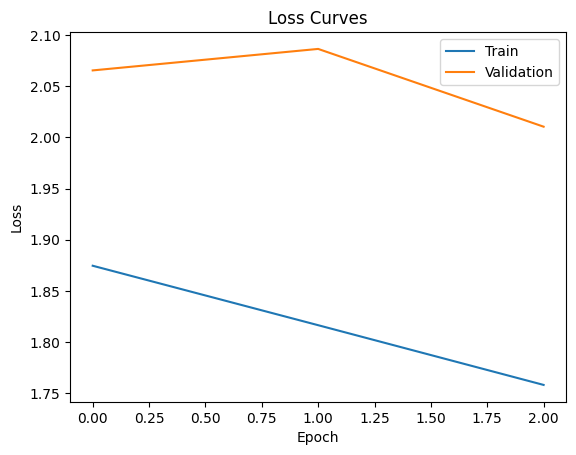

In [32]:
plt.plot(train_losses, label="Train")

plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curves")

plt.legend()

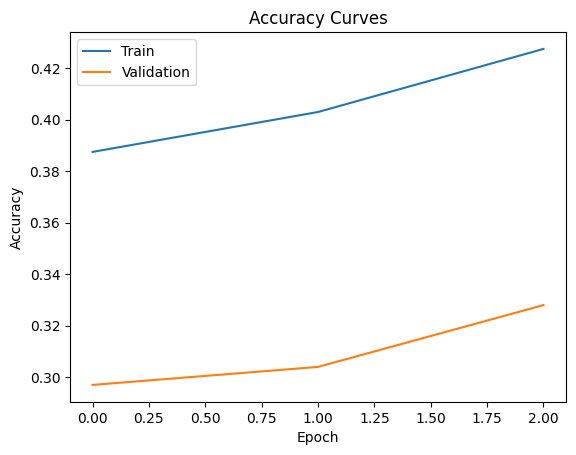

In [28]:
plt.plot(train_accuracies, label="Train")

plt.plot(val_accuracies, label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curves")

plt.legend()